In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not found")


CUDA available: True
GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!pip install -q torch torchvision torchaudio scikit-learn tqdm pandas

In [4]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report


In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


In [6]:
BASE_DIR = Path("/content")
WORK_DIR = BASE_DIR / "stanford_dogs_lab"
RAW_DIR = WORK_DIR / "raw"
SPLIT_DIR = WORK_DIR / "data"

DRIVE_DIR = Path("/content/drive/MyDrive/stanford_dogs_lab")
MODELS_DIR = DRIVE_DIR / "models"
RESULTS_DIR = DRIVE_DIR / "results"

WORK_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("WORK_DIR:", WORK_DIR)
print("RAW_DIR:", RAW_DIR)
print("SPLIT_DIR:", SPLIT_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)


WORK_DIR: /content/stanford_dogs_lab
RAW_DIR: /content/stanford_dogs_lab/raw
SPLIT_DIR: /content/stanford_dogs_lab/data
MODELS_DIR: /content/drive/MyDrive/stanford_dogs_lab/models
RESULTS_DIR: /content/drive/MyDrive/stanford_dogs_lab/results


In [9]:
%cd /content/stanford_dogs_lab/raw

!wget -O images.tar http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
!tar -xf images.tar


/content/stanford_dogs_lab/raw
--2026-03-20 12:31:25--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘images.tar’

images.tar          100%[===================>] 756.82M  34.3MB/s    in 38s     

2026-03-20 12:32:03 (20.1 MB/s) - ‘images.tar’ saved [793579520/793579520]



In [10]:
images_root = Path("/content/stanford_dogs_lab/raw/Images")
print("Exists:", images_root.exists())

class_dirs = [p for p in images_root.iterdir() if p.is_dir()]
print("Number of classes:", len(class_dirs))
print("First 5 classes:", [p.name for p in class_dirs[:5]])


Exists: True
Number of classes: 120
First 5 classes: ['n02098413-Lhasa', 'n02086079-Pekinese', 'n02112706-Brabancon_griffon', 'n02113712-miniature_poodle', 'n02095314-wire-haired_fox_terrier']


In [11]:
def split_dataset(source_dir, dest_dir, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    random.seed(seed)

    source_dir = Path(source_dir)
    dest_dir = Path(dest_dir)

    for split in ["train", "val", "test"]:
        (dest_dir / split).mkdir(parents=True, exist_ok=True)

    class_folders = [p for p in source_dir.iterdir() if p.is_dir()]

    for class_folder in tqdm(class_folders, desc="Splitting classes"):
        images = list(class_folder.glob("*"))
        images = [img for img in images if img.is_file()]
        random.shuffle(images)

        n = len(images)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        train_imgs = images[:n_train]
        val_imgs = images[n_train:n_train+n_val]
        test_imgs = images[n_train+n_val:]

        for split_name, split_imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
            target_class_dir = dest_dir / split_name / class_folder.name
            target_class_dir.mkdir(parents=True, exist_ok=True)

            for img_path in split_imgs:
                target_path = target_class_dir / img_path.name
                if not target_path.exists():
                    shutil.copy(img_path, target_path)

    print("Dataset split completed.")


In [12]:
split_dataset(images_root, SPLIT_DIR)

Splitting classes: 100%|██████████| 120/120 [00:06<00:00, 19.65it/s]

Dataset split completed.


In [13]:
for split in ["train", "val", "test"]:
    split_path = SPLIT_DIR / split
    num_classes = len([p for p in split_path.iterdir() if p.is_dir()])
    num_images = sum(len(list(cls.glob("*"))) for cls in split_path.iterdir() if cls.is_dir())
    print(f"{split}: classes={num_classes}, images={num_images}")


train: classes=120, images=14355
val: classes=120, images=3025
test: classes=120, images=3200


In [14]:
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [15]:
train_ds = datasets.ImageFolder(SPLIT_DIR / "train", transform=train_tfms)
val_ds   = datasets.ImageFolder(SPLIT_DIR / "val", transform=eval_tfms)
test_ds  = datasets.ImageFolder(SPLIT_DIR / "test", transform=eval_tfms)

NUM_CLASSES = len(train_ds.classes)

print("Classes:", NUM_CLASSES)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))


Classes: 120
Train size: 14355
Val size: 3025
Test size: 3200


In [16]:
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders created successfully")


DataLoaders created successfully


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [18]:
def build_resnet50(num_classes, pretrained=True):
    if pretrained:
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        model = models.resnet50(weights=weights)
    else:
        model = models.resnet50(weights=None)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [20]:
@torch.no_grad()
def evaluate_loss_acc(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [21]:
def fit_model(model, train_loader, val_loader, device, epochs=5, lr=1e-4, optimizer_name="adam", save_name="temp_model"):
    criterion = nn.CrossEntropyLoss()

    model = model.to(device)

    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
        swa_model = None
        swa_scheduler = None

    elif optimizer_name == "averaged_adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
        swa_model = AveragedModel(model).to(device)
        swa_scheduler = SWALR(optimizer, swa_lr=lr * 0.5)

    else:
        raise ValueError("Unknown optimizer_name")

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_path = MODELS_DIR / f"{save_name}_best_tmp.pth"

    for epoch in range(epochs):
        print(f"\nEpoch [{epoch+1}/{epochs}]")

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_loss_acc(model, val_loader, criterion, device)

        if optimizer_name == "averaged_adam" and epoch >= max(1, epochs // 2):
            swa_model.update_parameters(model)
            swa_scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f}")
        print(f"val_loss:   {val_loss:.4f} | val_acc:   {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)
            print("Best model updated and saved.")

    if optimizer_name == "averaged_adam" and swa_model is not None:
        update_bn(train_loader, swa_model, device=device)
        return swa_model, history

    model.load_state_dict(torch.load(best_path, map_location=device))
    model = model.to(device)
    return model, history


In [22]:
@torch.no_grad()
def get_classification_metrics(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return precision, recall, f1, all_labels, all_preds


In [23]:
def plot_history(history, title="Training history"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [24]:
def save_experiment_results(exp_name, model, history, precision, recall, f1):
    model_path = MODELS_DIR / f"{exp_name}.pth"
    metrics_path = RESULTS_DIR / f"{exp_name}_metrics.txt"
    history_path = RESULTS_DIR / f"{exp_name}_history.csv"

    torch.save(model.state_dict(), model_path)

    with open(metrics_path, "w") as f:
        f.write(f"Experiment: {exp_name}\n")
        f.write(f"Precision: {precision}\n")
        f.write(f"Recall: {recall}\n")
        f.write(f"F1: {f1}\n")

    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)

    print("Saved model to:", model_path)
    print("Saved metrics to:", metrics_path)
    print("Saved history to:", history_path)


In [25]:
model_1 = build_resnet50(NUM_CLASSES, pretrained=True)

model_1, history_1 = fit_model(
    model=model_1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=5,
    lr=1e-4,
    optimizer_name="adam",
    save_name="exp1_pretrained_adam"
)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 123MB/s]



Epoch [1/5]


train_loss: 2.3537 | train_acc: 0.4895
val_loss:   0.7056 | val_acc:   0.8017
Best model updated and saved.

Epoch [2/5]


train_loss: 1.1690 | train_acc: 0.6908
val_loss:   0.5789 | val_acc:   0.8255
Best model updated and saved.

Epoch [3/5]


train_loss: 0.9961 | train_acc: 0.7284
val_loss:   0.5519 | val_acc:   0.8248

Epoch [4/5]


train_loss: 0.8897 | train_acc: 0.7553
val_loss:   0.5867 | val_acc:   0.8228

Epoch [5/5]


train_loss: 0.8376 | train_acc: 0.7712
val_loss:   0.5759 | val_acc:   0.8165


In [26]:
precision_1, recall_1, f1_1, y_true_1, y_pred_1 = get_classification_metrics(model_1, test_loader, device)

print("Experiment 1: Pretrained + Adam")
print("Precision:", precision_1)
print("Recall:", recall_1)
print("F1:", f1_1)


Experiment 1: Pretrained + Adam
Precision: 0.835626148956166
Recall: 0.8150847393635234
F1: 0.8101409123238726


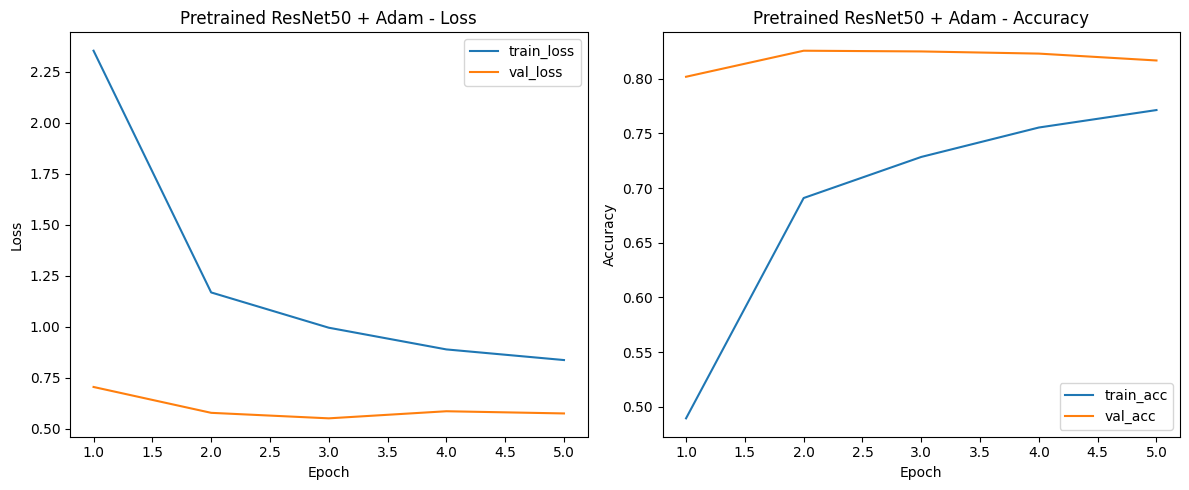

In [27]:
plot_history(history_1, title="Pretrained ResNet50 + Adam")

In [28]:
save_experiment_results(
    exp_name="exp1_pretrained_adam",
    model=model_1,
    history=history_1,
    precision=precision_1,
    recall=recall_1,
    f1=f1_1
)


Saved model to: /content/drive/MyDrive/stanford_dogs_lab/models/exp1_pretrained_adam.pth
Saved metrics to: /content/drive/MyDrive/stanford_dogs_lab/results/exp1_pretrained_adam_metrics.txt
Saved history to: /content/drive/MyDrive/stanford_dogs_lab/results/exp1_pretrained_adam_history.csv


In [29]:
model_2 = build_resnet50(NUM_CLASSES, pretrained=True)

model_2, history_2 = fit_model(
    model=model_2,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=5,
    lr=1e-4,
    optimizer_name="averaged_adam",
    save_name="exp2_pretrained_averaged_adam"
)



Epoch [1/5]


train_loss: 2.3482 | train_acc: 0.5009
val_loss:   0.7074 | val_acc:   0.7947
Best model updated and saved.

Epoch [2/5]


train_loss: 1.1679 | train_acc: 0.6926
val_loss:   0.5845 | val_acc:   0.8218
Best model updated and saved.

Epoch [3/5]


train_loss: 1.0060 | train_acc: 0.7239
val_loss:   0.5716 | val_acc:   0.8258
Best model updated and saved.

Epoch [4/5]


train_loss: 0.9145 | train_acc: 0.7524
val_loss:   0.5778 | val_acc:   0.8155

Epoch [5/5]


train_loss: 0.8343 | train_acc: 0.7702
val_loss:   0.5589 | val_acc:   0.8304
Best model updated and saved.


In [30]:
precision_2, recall_2, f1_2, y_true_2, y_pred_2 = get_classification_metrics(model_2, test_loader, device)

print("Experiment 2: Pretrained + Averaged Adam")
print("Precision:", precision_2)
print("Recall:", recall_2)
print("F1:", f1_2)


Experiment 2: Pretrained + Averaged Adam
Precision: 0.8569249661502985
Recall: 0.8486955937948056
F1: 0.8472517521942876


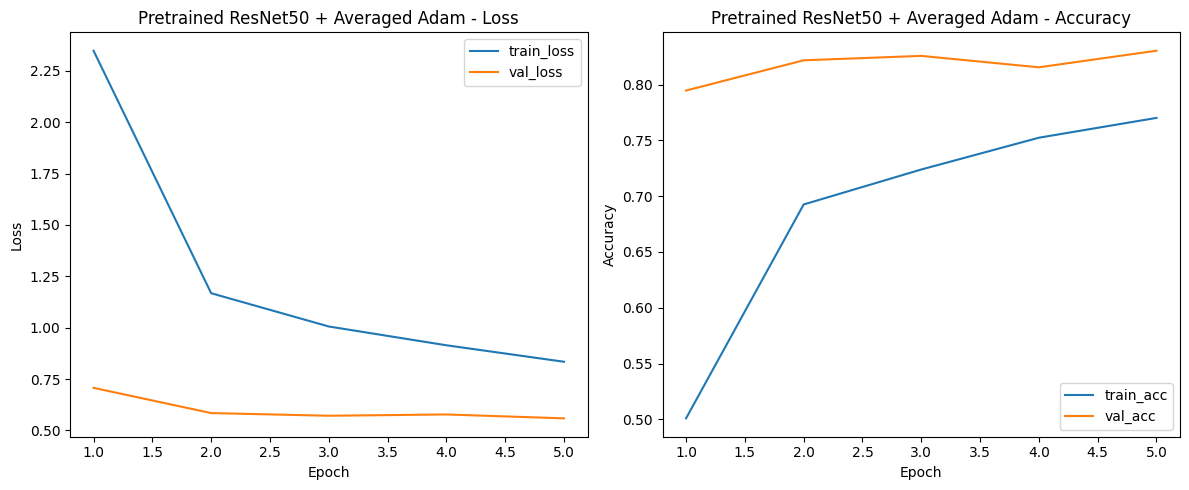

In [31]:
plot_history(history_2, title="Pretrained ResNet50 + Averaged Adam")

In [32]:
save_experiment_results(
    exp_name="exp2_pretrained_averaged_adam",
    model=model_2,
    history=history_2,
    precision=precision_2,
    recall=recall_2,
    f1=f1_2
)


Saved model to: /content/drive/MyDrive/stanford_dogs_lab/models/exp2_pretrained_averaged_adam.pth
Saved metrics to: /content/drive/MyDrive/stanford_dogs_lab/results/exp2_pretrained_averaged_adam_metrics.txt
Saved history to: /content/drive/MyDrive/stanford_dogs_lab/results/exp2_pretrained_averaged_adam_history.csv


In [33]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        # Свёрточные слои
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)

        # Полносвязные слои
        self.fc1 = nn.Linear(256 * 32 * 32, 1024)  # 32x32 - размер после свертки и pooling
        self.fc2 = nn.Linear(1024, num_classes)

        # Слои активации и pooling
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # Проходим через все слои
        x = self.relu(self.conv1(x))
        x = self.maxpool(x)
        x = self.relu(self.conv2(x))
        x = self.maxpool(x)
        x = self.relu(self.conv3(x))
        x = self.maxpool(x)

        # Переводим вектор в одномерный для полносвязного слоя
        x = x.view(x.size(0), -1)

        # Полносвязные слои
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [34]:
def train_model_with_scratch(model, train_loader, val_loader, criterion, optimizer, device, epochs=5):
    model.to(device)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Валидация
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / total
        val_acc = correct / total

        # Сохраняем историю
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}")

    return model, history

In [36]:
# Создание модели с нуля
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        # Свёрточные слои
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)

        # Полносвязные слои
        self.fc1 = nn.Linear(256 * 28 * 28, 1024)  # Размер после свертки и pooling
        self.fc2 = nn.Linear(1024, num_classes)

        # Слои активации и pooling
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # Проходим через все слои
        x = self.relu(self.conv1(x))
        x = self.maxpool(x)
        x = self.relu(self.conv2(x))
        x = self.maxpool(x)
        x = self.relu(self.conv3(x))
        x = self.maxpool(x)

        # Переводим вектор в одномерный для полносвязного слоя
        x = x.view(x.size(0), -1)

        # Полносвязные слои
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [37]:
# Обучение модели с нуля
def train_model_with_scratch(model, train_loader, val_loader, criterion, optimizer, device, epochs=5):
    model.to(device)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Валидация
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / total
        val_acc = correct / total

        # Сохраняем историю
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}")

    return model, history

In [38]:
# Определяем количество классов
NUM_CLASSES = len(train_ds.classes)

# Переводим модель на GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=NUM_CLASSES)

# Определяем оптимизатор и loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# Обучаем модель
model, history = train_model_with_scratch(model, train_loader, val_loader, criterion, optimizer, device, epochs=5)

Epoch 1/5
Train Loss: 4.6825 | Train Accuracy: 0.0210
Val Loss: 4.5164 | Val Accuracy: 0.0344
Epoch 2/5
Train Loss: 4.4738 | Train Accuracy: 0.0410
Val Loss: 4.3479 | Val Accuracy: 0.0519
Epoch 3/5
Train Loss: 4.3370 | Train Accuracy: 0.0583
Val Loss: 4.2287 | Val Accuracy: 0.0641
Epoch 4/5
Train Loss: 4.1997 | Train Accuracy: 0.0815
Val Loss: 4.1186 | Val Accuracy: 0.0853
Epoch 5/5
Train Loss: 4.1008 | Train Accuracy: 0.0917
Val Loss: 4.0574 | Val Accuracy: 0.0995


In [40]:
# Считаем метрики для 3-го эксперимента
precision_3, recall_3, f1_3, all_labels_3, all_preds_3 = get_classification_metrics(model, test_loader, device)

print("Experiment 3: ResNet50 from scratch + Adam")
print("Precision:", precision_3)
print("Recall:", recall_3)
print("F1:", f1_3)

Experiment 3: ResNet50 from scratch + Adam
Precision: 0.0956091840946726
Recall: 0.09788671328944136
F1: 0.08131799009327309


In [43]:
def save_history_plot(history, title, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # График потерь
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # График точности
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

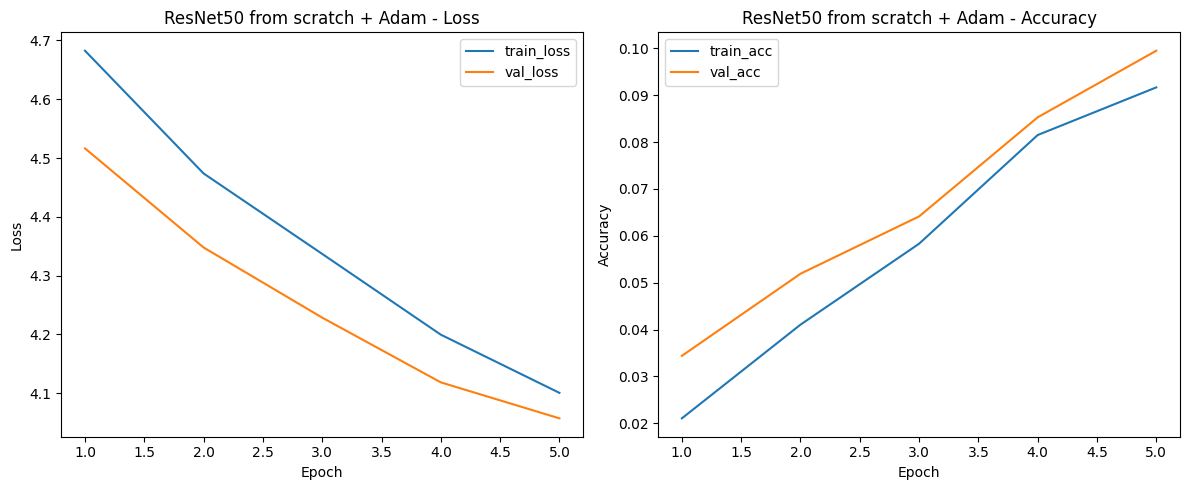

In [44]:
save_history_plot(history, "ResNet50 from scratch + Adam", RESULTS_DIR / "exp3_plot.png")

In [45]:
# Сохраняем результаты для 3-го эксперимента
save_experiment_results(
    exp_name="exp3_scratch_adam",
    model=model,
    history=history,
    precision=precision_3,
    recall=recall_3,
    f1=f1_3
)

Saved model to: /content/drive/MyDrive/stanford_dogs_lab/models/exp3_scratch_adam.pth
Saved metrics to: /content/drive/MyDrive/stanford_dogs_lab/results/exp3_scratch_adam_metrics.txt
Saved history to: /content/drive/MyDrive/stanford_dogs_lab/results/exp3_scratch_adam_history.csv


In [46]:
import pandas as pd

# Результаты для каждого эксперимента
results = [
    ["Pretrained + Adam", precision_1, recall_1, f1_1],
    ["Pretrained + Averaged Adam", precision_2, recall_2, f1_2],
    ["ResNet50 from scratch + Adam", precision_3, recall_3, f1_3],
]

# Создание DataFrame
df_results = pd.DataFrame(results, columns=["Experiment", "Precision", "Recall", "F1"])

# Сохранение в CSV файл
final_results_path = RESULTS_DIR / "final_results.csv"
df_results.to_csv(final_results_path, index=False)

# Выводим таблицу для проверки
df_results

,Experiment,Precision,Recall,F1
0,Pretrained + Adam,0.835626,0.815085,0.810141
1,Pretrained + Averaged Adam,0.856925,0.848696,0.847252
2,ResNet50 from scratch + Adam,0.095609,0.097887,0.081318


In [47]:
# Сохраняем результаты для всех экспериментов
save_experiment_results(
    exp_name="exp1_pretrained_adam",
    model=model_1,
    history=history_1,
    precision=precision_1,
    recall=recall_1,
    f1=f1_1
)

save_experiment_results(
    exp_name="exp2_pretrained_averaged_adam",
    model=model_2,
    history=history_2,
    precision=precision_2,
    recall=recall_2,
    f1=f1_2
)

save_experiment_results(
    exp_name="exp3_scratch_adam",
    model=model,
    history=history,
    precision=precision_3,
    recall=recall_3,
    f1=f1_3
)

Saved model to: /content/drive/MyDrive/stanford_dogs_lab/models/exp1_pretrained_adam.pth
Saved metrics to: /content/drive/MyDrive/stanford_dogs_lab/results/exp1_pretrained_adam_metrics.txt
Saved history to: /content/drive/MyDrive/stanford_dogs_lab/results/exp1_pretrained_adam_history.csv
Saved model to: /content/drive/MyDrive/stanford_dogs_lab/models/exp2_pretrained_averaged_adam.pth
Saved metrics to: /content/drive/MyDrive/stanford_dogs_lab/results/exp2_pretrained_averaged_adam_metrics.txt
Saved history to: /content/drive/MyDrive/stanford_dogs_lab/results/exp2_pretrained_averaged_adam_history.csv
Saved model to: /content/drive/MyDrive/stanford_dogs_lab/models/exp3_scratch_adam.pth
Saved metrics to: /content/drive/MyDrive/stanford_dogs_lab/results/exp3_scratch_adam_metrics.txt
Saved history to: /content/drive/MyDrive/stanford_dogs_lab/results/exp3_scratch_adam_history.csv
